## Introduction

This notebook explores [Youtube Duration Data](https://github.com/sTechLab/YouTubeDurationData/tree/master) found on GitHub. Out of the two datasets the author gathered, we will look at the ``RandomVideo_dataTable.csv`` which takes a random sample of YouTube videos by using the YouTube API.

We will be using this dataset to look into how video length affects audience retention and different forms of engagement on YouTube.

Reference(s):
1. Park, M., Naaman, M., & Berger, J. (2016). A Data-driven Study of View Duration on YouTube. Tenth International Conference on Web and Social Media (ICWSM 2016). Cologne, Germany, May 2016.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import dataset
yt = pd.read_csv('https://raw.githubusercontent.com/sTechLab/YouTubeDurationData/refs/heads/master/RandomVideo_dataTable.csv')
yt.head()

,video_id,viewCount,favoriteCount,dislikeCount,likeCount,duration,publishedAt,elapsed_time,category_term,watchTime,...,pos,compound,num_EnglishComments,engagement,comment_percentage,discussion_density,like_percentage,dislike_percentage,like_dislike_ratio,share_percentage
0,aHMER1h4BNU,129260,0,9,174,163,2012-08-21T15:56:15.000Z,1090,Film & Animation,0.000000,...,0.143,0.9988,53,0.000000,0.000944,0.377049,0.001346,0.000070,0.950820,0.001632
1,jB81uS22Nuk,8633,0,1,38,388,2015-04-01T06:02:45.000Z,137,People & Blogs,20956.116670,...,0.056,-0.9999,46,0.476564,0.010078,0.528736,0.004402,0.000116,0.974359,0.001969
2,qAKlb2FR6YQ,1682,0,0,47,608,2014-03-18T19:40:24.000Z,516,Entertainment,4147.383333,...,0.200,0.9958,7,0.245225,0.017241,0.310345,0.027943,0.000000,1.000000,0.000595
3,EkiLeo66rq0,83298,0,21,259,242,2015-04-19T01:48:46.000Z,119,Music,130568.666700,...,0.054,0.9673,14,0.435775,0.000528,0.340909,0.003109,0.000252,0.925000,0.002269
4,0dEc-UyQf58,10191,0,1,244,285,2015-05-15T01:43:31.000Z,93,Gaming,18159.716670,...,0.266,0.9998,18,0.453242,0.005789,0.305085,0.023943,0.000098,0.995918,0.001079


In [3]:
print('Shape:', yt.shape)

print('\nColumns:', yt.columns)

Shape: (1125, 108)

Columns: Index(['video_id', 'viewCount', 'favoriteCount', 'dislikeCount', 'likeCount',
       'duration', 'publishedAt', 'elapsed_time', 'category_term', 'watchTime',
       ...
       'pos', 'compound', 'num_EnglishComments', 'engagement',
       'comment_percentage', 'discussion_density', 'like_percentage',
       'dislike_percentage', 'like_dislike_ratio', 'share_percentage'],
      dtype='object', length=108)


There are 108 columns in this dataset, but we won't be needing to use all of them. We will focus on variables that are essential to our research topic and ignore the rest.

In [4]:
yt['averageViewDuration'].describe()

count    1125.000000
mean      231.154512
std       225.979018
min         0.000000
25%        82.922908
50%       162.554294
75%       305.012011
max      2067.015609
Name: averageViewDuration, dtype: float64

Text(0.5, 1.0, 'Distribution of average view duration')

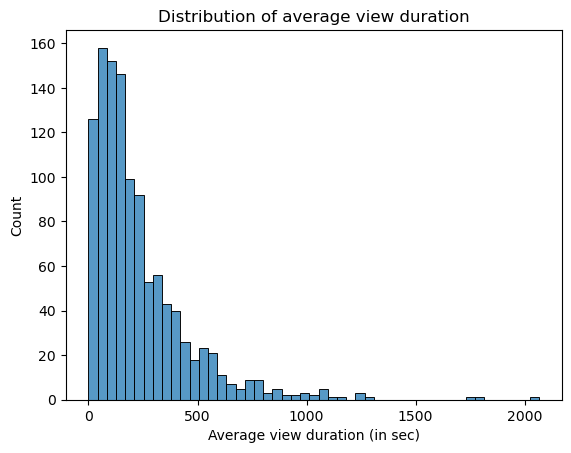

In [5]:
sns.histplot(yt, x = 'averageViewDuration')

plt.xlabel('Average view duration (in sec)')
plt.title('Distribution of average view duration')

It's a bit hard to interpret this plot since there are many bins, but we can see that the graph is skewed to the right and that there are more videos with an average watch duration of less than 500 seconds.

Text(0.5, 1.0, 'Distribution of average view duration')

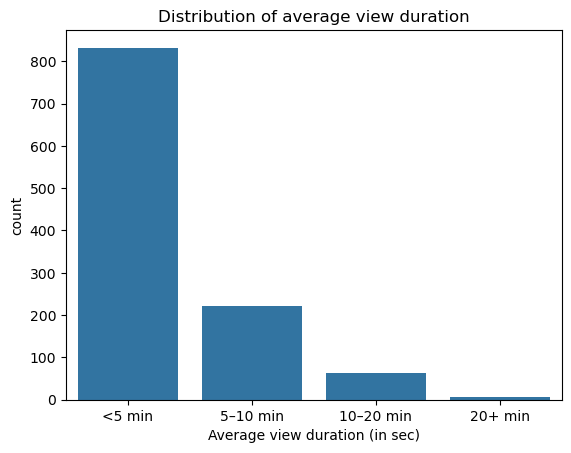

In [6]:
# bin watch time
bins = [0, 300, 600, 1200, float("inf")]
labels = ["<5 min", "5–10 min", "10–20 min", "20+ min"]

yt["avgViewDuration_bins"] = pd.cut(
    yt["averageViewDuration"],
    bins = bins,
    labels = labels,
    right = False
)

sns.countplot(
    data = yt,
    x = "avgViewDuration_bins",
    order = labels
)

plt.xlabel('Average view duration (in sec)')
plt.title('Distribution of average view duration')

Based on the plot, the average view duration is less than 5 minutes overall.

Text(0.5, 1.0, 'How does video length relate to average watch time?')

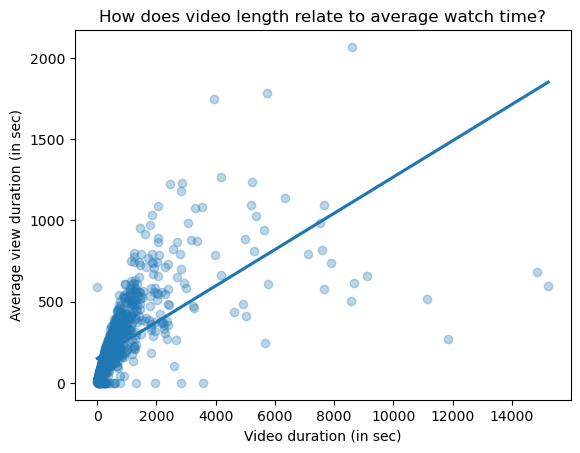

In [7]:
# scatterplot b/w avg view duration & duration (measures how long people actually watch and how long the video actually is)
sns.regplot(yt, x = 'duration', y = 'averageViewDuration', scatter_kws = {'alpha': 0.3}, ci = None)

plt.xlabel('Video duration (in sec)')
plt.ylabel('Average view duration (in sec)')
plt.title('How does video length relate to average watch time?')

In [8]:
corr = yt['duration'].corr(yt['averageViewDuration'])
print("Correlation r:", corr)

Correlation r: 0.6464448571515122


When using a scatterplot to view the relationship between how long a video is and how long people actually watch the video, there appears to be a positive correlation (r = 0.64) especially when fitting a regression line to the data, but is that really the case? The trend line may appear this way due to outliers (e.g the data points that're way over 14000 seconds/3 hours) and large variation within the data. However, we can still see data points around the 8000 and 10000 video duration marks that have large differences in average watch time. Longer videos can either have a low or high average watchtime, so it's not always consistent.

Maybe we can try to look at videos with a duration of less than 600 seconds/10 minutes and see how the relationship may change.

Correlation (<= 600 sec): 0.7865369819214956


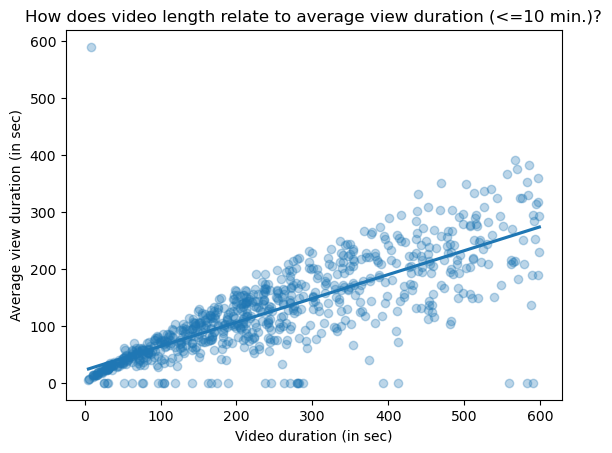

In [9]:
# filtering previous plot by including videos <10min long
yt_600 = yt[yt['duration'] <= 600]
corr_600 = yt_600['duration'].corr(yt_600['averageViewDuration'])

print("Correlation (<= 600 sec):", corr_600)

sns.regplot(
    x = 'duration',
    y = 'averageViewDuration',
    data = yt_600,
    scatter_kws = {'alpha': 0.3},
    ci = None
)

plt.xlabel('Video duration (in sec)')
plt.ylabel('Average view duration (in sec)')
plt.title('How does video length relate to average view duration (<=10 min.)?')
plt.show()

This plot may be more informative than the previous one since it's not being influenced by large outliers. Among the cluster of shorter videos, the regression line suggests that shorter videos have better retention compared to longer videos.

Now that we've explored the relationship between video duration and average view duration, let's look at how average view duration relates to engagement on YouTube.

Text(0.5, 1.0, 'How does view duration affect engagement on average?')

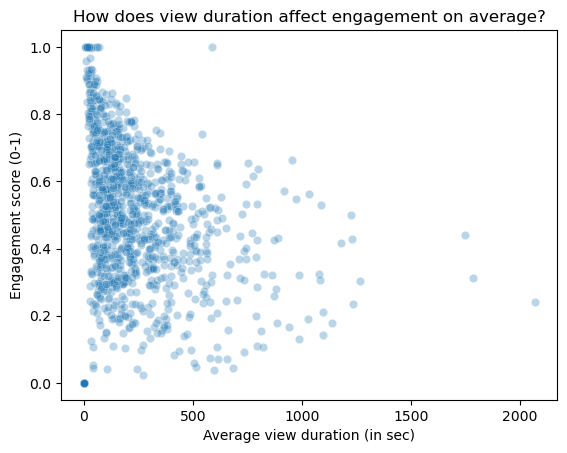

In [10]:
# scatterplot b/w avg view duration & engagement
sns.scatterplot(yt, x = 'averageViewDuration', y = 'engagement', alpha = 0.3)

plt.xlabel('Average view duration (in sec)')
plt.ylabel('Engagement score (0-1)')
plt.title('How does view duration affect engagement on average?')

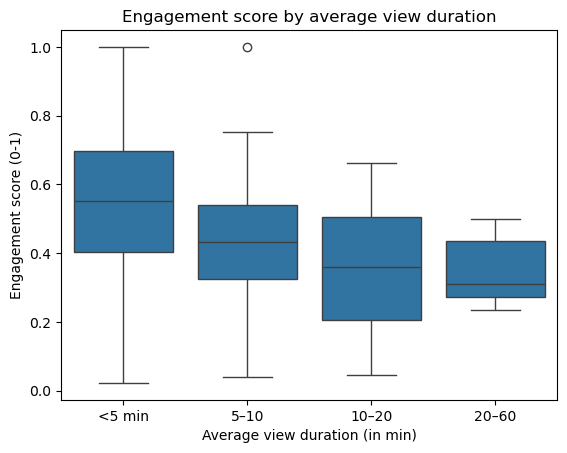

In [11]:
# boxplot b/w video avg video duration & engagement
yt["avgDuration_bin"] = pd.cut(
    yt["averageViewDuration"],
    bins = [0, 300, 600, 1200, 3600],
    labels = ["<5 min", "5–10", "10–20", "20–60"]
)

sns.boxplot(data = yt, x = "avgDuration_bin", y = "engagement")
plt.title("Engagement score by average view duration")
plt.xlabel("Average view duration (in min)")
plt.ylabel("Engagement score (0-1)")
plt.show()

In [12]:
yt.groupby('avgDuration_bin')['engagement'].describe()

C:\Users\User\AppData\Local\Temp\ipykernel_23836\2488574542.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yt.groupby('avgDuration_bin')['engagement'].describe()


,count,mean,std,min,25%,50%,75%,max
avgDuration_bin,,,,,,,,
<5 min,795.0,0.549350,0.200338,0.022756,0.403612,0.551417,0.696230,1.000000
5–10,222.0,0.425479,0.160625,0.039202,0.324562,0.431457,0.540256,1.000000
10–20,64.0,0.358244,0.174437,0.045834,0.206604,0.361359,0.505004,0.663031
20–60,7.0,0.351391,0.104511,0.236183,0.271774,0.311099,0.434655,0.499596


This boxplot shows how engagement scores are more likely to vary more if a user's average video duration is less than 5 minutes, but at the same time it also has the highest median engagement. As average watch time increases, we can see that the engagement scores tend to decrease. In conjunction with the summary statistics table, the average engagement score is very similar between 10-20 and 20-60 minutes of average watch time.

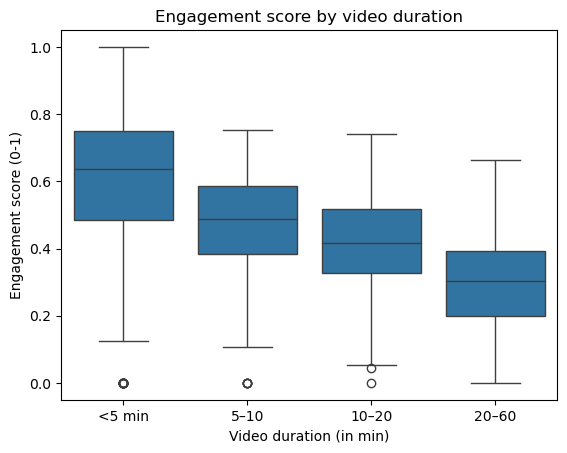

In [13]:
# boxplot b/w video avg video duration & engagement
yt["duration_bin"] = pd.cut(
    yt["duration"],
    bins = [0, 300, 600, 1200, 3600],
    labels = ["<5 min", "5–10", "10–20", "20–60"]
)

sns.boxplot(data = yt, x = "duration_bin", y = "engagement")
plt.title("Engagement score by video duration")
plt.xlabel("Video duration (in min)")
plt.ylabel("Engagement score (0-1)")
plt.show()

In [14]:
yt.groupby('duration_bin')['engagement'].describe()

C:\Users\User\AppData\Local\Temp\ipykernel_23836\3135767319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yt.groupby('duration_bin')['engagement'].describe()


,count,mean,std,min,25%,50%,75%,max
duration_bin,,,,,,,,
<5 min,511.0,0.603246,0.224645,0.0,0.484467,0.635572,0.750860,1.000000
5–10,256.0,0.477373,0.146198,0.0,0.384007,0.486876,0.586577,0.753944
10–20,205.0,0.412530,0.136206,0.0,0.328627,0.417912,0.517522,0.739444
20–60,122.0,0.304356,0.140569,0.0,0.197868,0.303546,0.393399,0.663031


Overall, the boxplot shows that engagement scores are more likely to decrease the longer a video is and that there is also more variability compared to other categories. This is supported by the summary statistics table above where engagement scores are higher on average and have greater variability when videos are less than 5 minutes long.

In [15]:
yt['like_dislike_ratio'].describe()

count    1123.000000
mean        0.937710
std         0.096731
min         0.074764
25%         0.928840
50%         0.970874
75%         0.990073
max         1.000000
Name: like_dislike_ratio, dtype: float64

Text(0.5, 1.0, 'How does video length relate to its like/dislike ratio?')

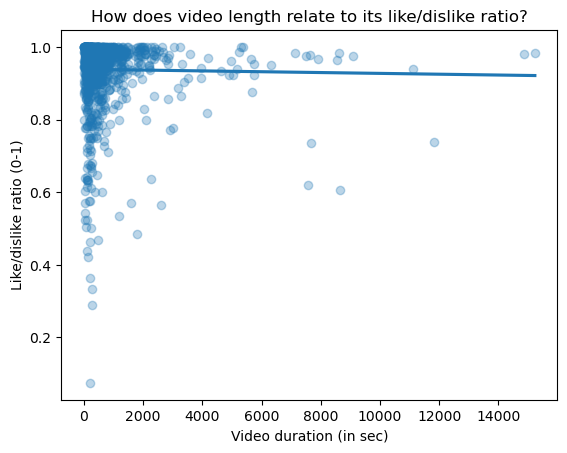

In [16]:
sns.regplot(yt, x = 'duration', y = 'like_dislike_ratio', scatter_kws = {'alpha': 0.3}, ci = None)

plt.ylabel('Like/dislike ratio (0-1)')
plt.xlabel('Video duration (in sec)')
plt.title('How does video length relate to its like/dislike ratio?')

In [17]:
ldr_duration_corr = yt['duration'].corr(yt['like_dislike_ratio'])

print("Correlation (<= 600 sec):", ldr_duration_corr)

Correlation (<= 600 sec): -0.015420568588444213


Correlation (<= 600 sec): 0.061378266755742324


Text(0.5, 1.0, 'How does video length relate to its like/dislike ratio (<=10 min.)?')

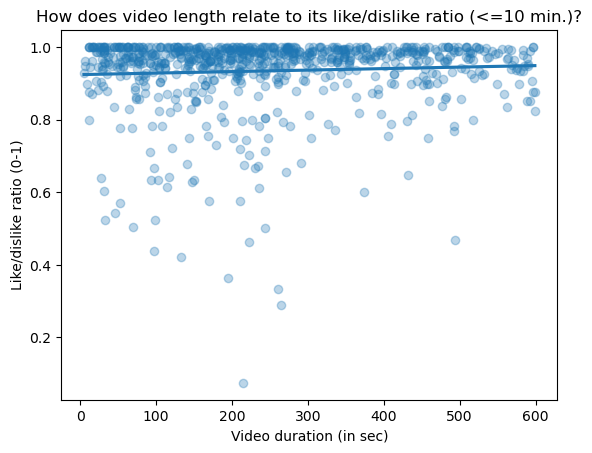

In [18]:
# 'zoom in' of previous graph
ldr_duration_corr_600 = yt_600['duration'].corr(yt_600['like_dislike_ratio'])

print("Correlation (<= 600 sec):", ldr_duration_corr_600)

sns.regplot(
    x = 'duration',
    y = 'like_dislike_ratio',
    data = yt_600,
    scatter_kws = {'alpha': 0.3},
    ci = None
)

plt.xlabel('Video duration (in sec)')
plt.ylabel('Like/dislike ratio (0-1)')
plt.title('How does video length relate to its like/dislike ratio (<=10 min.)?')

The scatterplot of the relation between video duration and like/dislike ratio shows little to no correlation. A lot of videos seem to have a high like/dislike ratio. While this may be a good thing, it could introduce positivity bias. The nearly flat trend line also suggests that video duration does not significantly impact the amount of likes and dislikes it gets.